In [15]:
import numpy as np
import numpy.random as rand
import matplotlib.pyplot as plt
from scipy.fft import rfft

In [16]:
def gaussian(x, mu, sig):
    return np.exp(-0.5*((x - mu)/sig)**2)/(sig*np.sqrt(2*np.pi))

prof_1024 = gaussian(np.linspace(0, 1, 1024), 0.5, 0.02)
prof_512 = gaussian(np.linspace(0, 1, 512), 0.5, 0.02)
fft_1024 = rfft(prof_1024)
fft_512 = rfft(prof_512)

$$\sigma_{k} = \sqrt{\frac{\langle{|a_j|^2}\rangle}{N_k}}$$

$$A = \langle |x_k| \rangle$$
$$\text{SNR} = \frac{A}{\sigma_k}$$

For this use case, let's imagine we want an SNR of 5.

In [33]:
sigma_k_1024 = np.sqrt(np.mean(np.abs(prof_1024)**2) / 1024)
sigma_k_512 = np.sqrt(np.mean(np.abs(prof_1024)**2) / 512)

#normalize each profile to SNR = 5:
snr_1024_og = np.mean(prof_1024) / sigma_k_1024 
snr_512_og = np.mean(prof_512) / sigma_k_512 

prof_1024 *= 5 / snr_1024_og 
prof_512 *= 5 / snr_512_og

prof_1024 += rand.normal(loc = 0, scale = sigma_k_1024, size = 1024)
prof_512 += rand.normal(loc = 0, scale = sigma_k_512, size = 512)

pows_1024 = np.abs(fft_1024)**2 
pows_512 = np.abs(fft_512)**2

Text(0.5, 0.98, 'signal A is different based on Nk --> same power for same SNR!')

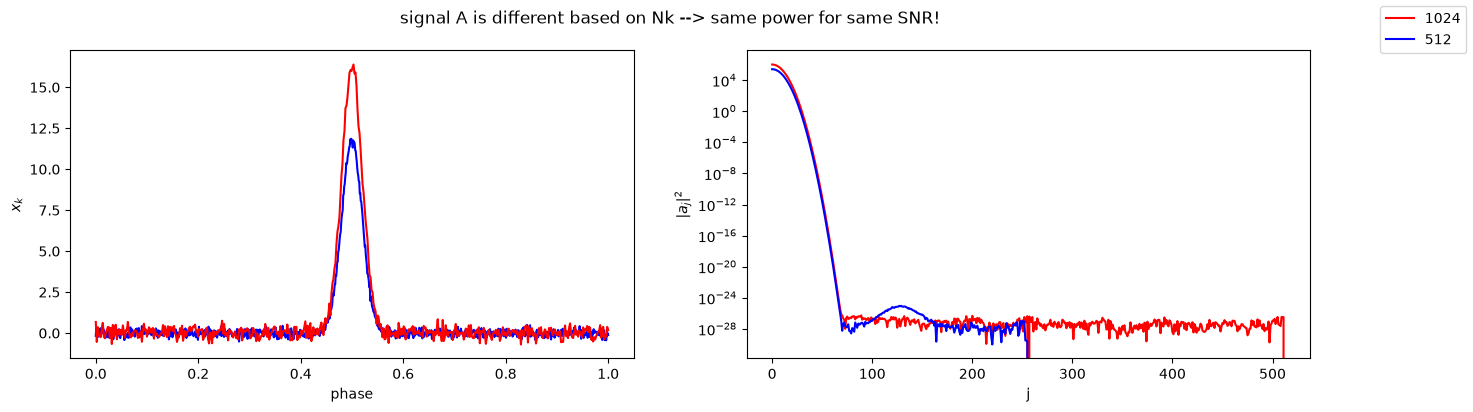

In [35]:
fig, ax = plt.subplots(1, 2, figsize = (16, 4))

ax[0].plot(np.linspace(0, 1, 1024), prof_1024, 'b')
ax[0].plot(np.linspace(0, 1, 512), prof_512, 'r')
ax[0].set_xlabel('phase')
ax[0].set_ylabel(r'$x_k$')

ax[1].plot(pows_1024, 'r', label = '1024')
ax[1].plot(pows_512, 'b', label = '512')
ax[1].set_yscale('log')
ax[1].set_xlabel('j')
ax[1].set_ylabel(r'$|a_j|^2$')

fig.legend()

fig.suptitle('signal A is different based on Nk --> same power for same SNR!')